# Case-02：二次靜不定連續梁 (Two-Span Continuous Beam)

本版直接從 GitHub 抓取最新的 `sd_framework.py` / `samples/model_two_span_beam.py`，不在 notebook 裡內嵌原始碼，避免兩份拷貝分岔。

## 題目摘要
| 項目 | 內容 |
|---|---|
| 結構 | 兩跨連續梁，A端固定、B中間滾支承、C遠端滾支承 |
| AB跨 | L₁ = 5.0 m, w₁ = 15.0 kN/m |
| BC跨 | L₂ = 6.0 m, w₂ = 20.0 kN/m |
| Dk (獨立位移自由度) | 2 (θ_B, θ_C) |
| 邊界/平衡條件 | θ_A=0 (固定端)，M_BA+M_BC=0 (中間節點平衡)，M_CB=0 (邊界條件) |

## 驗證方式
結構受力圖 → 剪力圖(SFD) → 彎矩圖(BMD)，跟 anastruct 逐一比對，並做剪力交叉檢查（AB跨、BC跨各兩端，共4個端點全核對）。

## 0. 安裝套件 + 抓取最新原始碼

In [1]:
try:
    import anastruct
    print("已偵測到 anastruct，略過安裝")
except ImportError:
    print("未偵測到 anastruct，開始安裝...")
    !pip install anastruct -q --break-system-packages
    try:
        import anastruct
        print("安裝完成，可以繼續往下執行")
    except ImportError:
        print("安裝後仍無法載入，這是 Colab 偶爾會發生的快取問題，"
              "請直接重新執行這個 cell 一次（通常第二次就會成功）")

%matplotlib inline

已偵測到 anastruct，略過安裝


In [2]:
# 從 GitHub 抓取最新版本的框架與模型原始碼 (main分支)
# 注意: sd_framework.py 在 repo 根目錄, model_two_span_beam.py 在 samples/
!wget -q -O sd_framework.py https://raw.githubusercontent.com/zhixiu0223/slope_deflection_framework/main/sd_framework.py
!wget -q -O model_two_span_beam.py https://raw.githubusercontent.com/zhixiu0223/slope_deflection_framework/main/samples/model_two_span_beam.py

from sd_framework import SlopeDeflectionSolver, member_shear_curve
from model_two_span_beam import TwoSpanBeamProblem
print("原始碼抓取完成")

原始碼抓取完成


## 1. 求解並產生「手寫詳解」風格輸出（步驟1~7）


【步驟 1】題目定義、幾何/材料參數與自由度標示


**① 結構定義、幾何與邊界條件**

**AB跨** $L_1=5.0$ m ($w_1=15.0$ kN/m), **BC跨** $L_2=6.0$ m ($w_2=20.0$ kN/m)

**邊界條件：** A端固定 ($\theta_A=0$)，B為中間滾支承 (連續，$\theta_B$ 兩跨共用)，C為遠端滾支承 ($M_{CB}=0$)

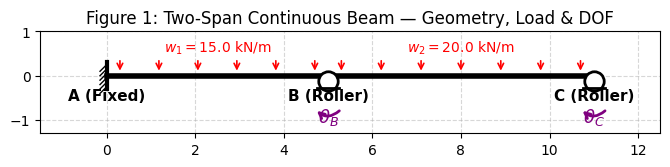

**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A端固定，$\theta_A=0$，不是未知量；B是**連續**的中間支承(不是鉸接釋放)，AB跨跟BC跨在B點共用**同一個**轉角 $\theta_B$——這裡如果誤把AB跨、BC跨各自設一個獨立轉角(當成B是鉸接)，會多出一個不存在的自由度，方程式數量對不上；C端是滾支承可自由轉動，$\theta_C$ 是第二個未知量。共兩個未知位移量 $\theta_B, \theta_C$——比 Case-01 多了一個節點(B)，新增的是**中間節點力矩平衡** $M_{BA}+M_{BC}=0$。


【步驟 2】寫出桿端彎矩方程式


**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：

$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$

其中 $\theta_i,\theta_j$ 為兩端轉角，$\psi=\Delta/L$ 為側移角（無側移時 $\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。

**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式：


【步驟 3】建立平衡方程式


**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）：

- 節點 B 力矩平衡 ΣM_B=0（AB跨與BC跨在B點交會，連續支承、無外加彎矩） M_BA + M_BC = 0

- C端邊界條件（滾支承不傳彎矩） M_CB = 0


【步驟 4】求解聯立方程式 (未知位移量)


**位移求解結果：**


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = 13.173 kN·m
M_{BA} = -67.404 kN·m
M_{BC} = 67.404 kN·m
M_{CB} = 0.000 kN·m

-> R_A (kN) = 26.654
-> R_B (kN) = 119.580
-> R_C (kN) = 48.766

【步驟 6】繪製剪力圖 (SFD)


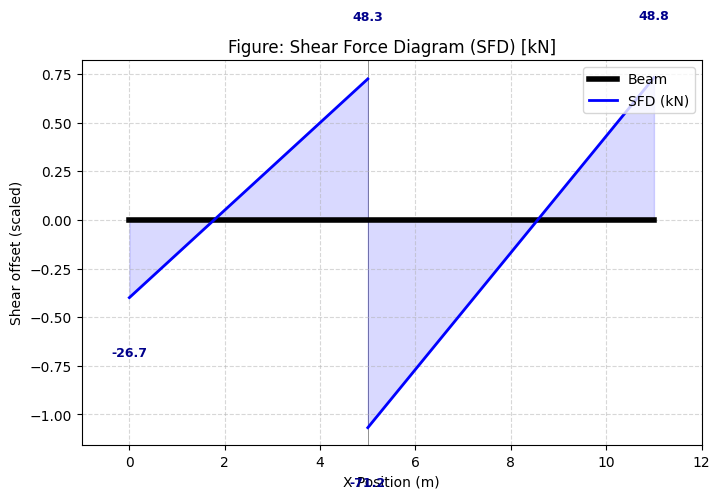


【步驟 7】繪製彎矩圖 (BMD)


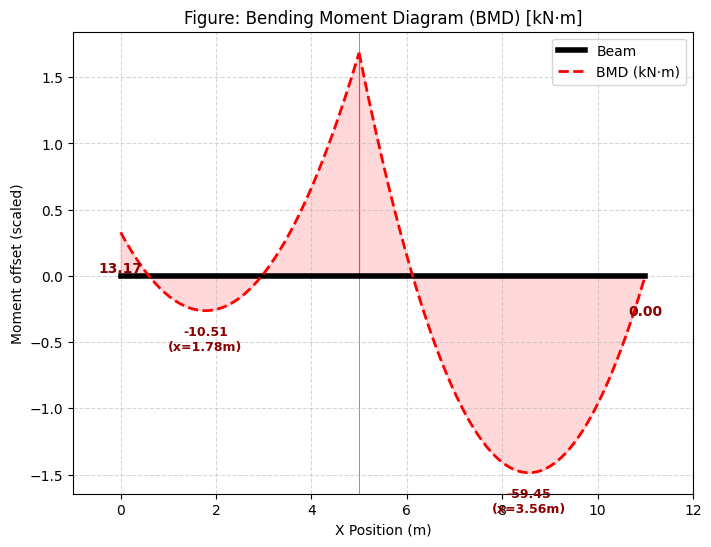

{'moments': {'M_{AB}': 13.173076923076923,
  'M_{BA}': -67.40384615384616,
  'M_{BC}': 67.40384615384615,
  'M_{CB}': 0.0},
 'reactions': {'R_A (kN)': 26.653846153846153,
  'R_B (kN)': 119.5801282051282,
  'R_C (kN)': 48.76602564102565},
 'solution': {theta_B: -45.1923076923077/EI, theta_C: 112.596153846154/EI}}

In [3]:
problem = TwoSpanBeamProblem(L1=5.0, L2=6.0, w1=15.0, w2=20.0)
solver = SlopeDeflectionSolver(problem)
solver.solve_and_report()

## 1b. 教學講義輸出（此 Case 教學詳解尚未實作，示範優雅跳過）

## 1. 結構受力圖與自由度

**AB跨** $L_1=5.0$ m ($w_1=15.0$ kN/m), **BC跨** $L_2=6.0$ m ($w_2=20.0$ kN/m)

**邊界條件：** A端固定 ($\theta_A=0$)，B為中間滾支承 (連續，$\theta_B$ 兩跨共用)，C為遠端滾支承 ($M_{CB}=0$)

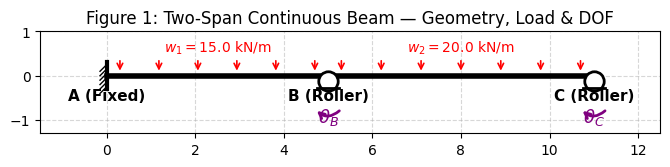

**⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A端固定，$\theta_A=0$，不是未知量；B是**連續**的中間支承(不是鉸接釋放)，AB跨跟BC跨在B點共用**同一個**轉角 $\theta_B$——這裡如果誤把AB跨、BC跨各自設一個獨立轉角(當成B是鉸接)，會多出一個不存在的自由度，方程式數量對不上；C端是滾支承可自由轉動，$\theta_C$ 是第二個未知量。共兩個未知位移量 $\theta_B, \theta_C$——比 Case-01 多了一個節點(B)，新增的是**中間節點力矩平衡** $M_{BA}+M_{BC}=0$。

## 2. 教學詳解與評分要點

(此模型尚未提供教學詳解)


## 3. 剪力圖 (SFD) 與彎矩圖 (BMD)

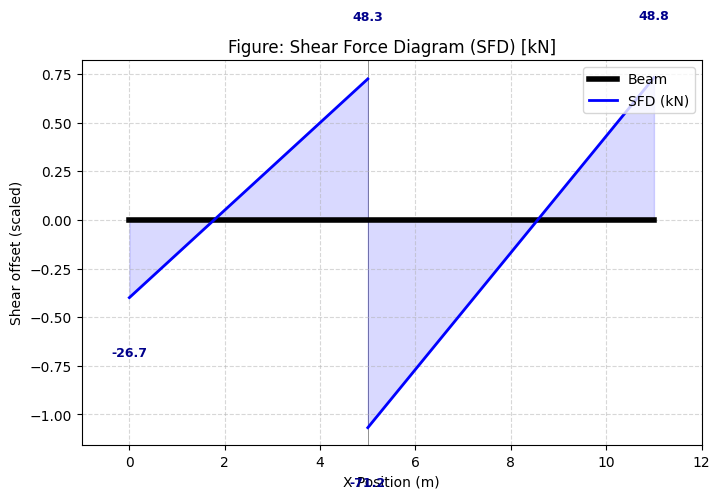

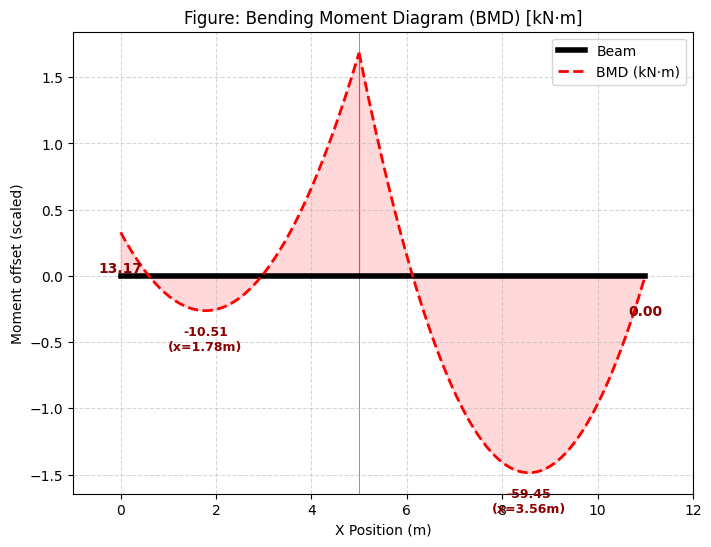

In [4]:
solver.print_teaching_handout()

## 2. anastruct 獨立建模驗證

A反力: {'id': 1, 'Fx': np.float64(-1.1940306291686696e-14), 'Fy': np.float64(-26.653851576920367), 'Tz': np.float64(-13.173070336541748), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
B反力: {'id': 2, 'Fx': np.float64(0.0), 'Fy': np.float64(-119.5801171650696), 'Tz': np.float64(1.4210854715202004e-14), 'ux': np.float64(4.822046771642705e-22), 'uy': np.float64(0.0), 'phi_z': np.float64(0.0030128190064110105)}
C反力: {'id': 3, 'Fx': np.float64(1.5777218104420236e-30), 'Fy': np.float64(-48.766031258010024), 'Tz': np.float64(0.0), 'ux': np.float64(7.02641101010794e-22), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0075064065032070006)}


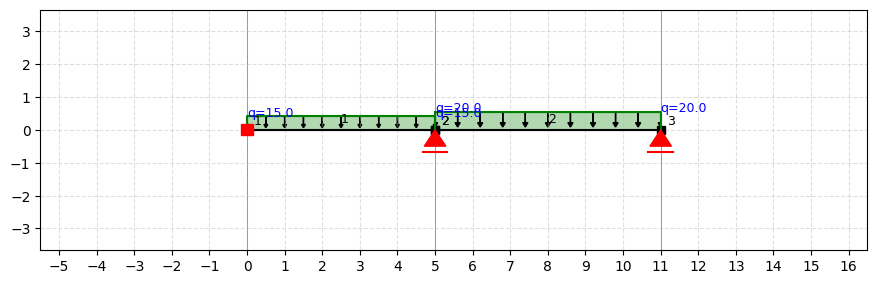

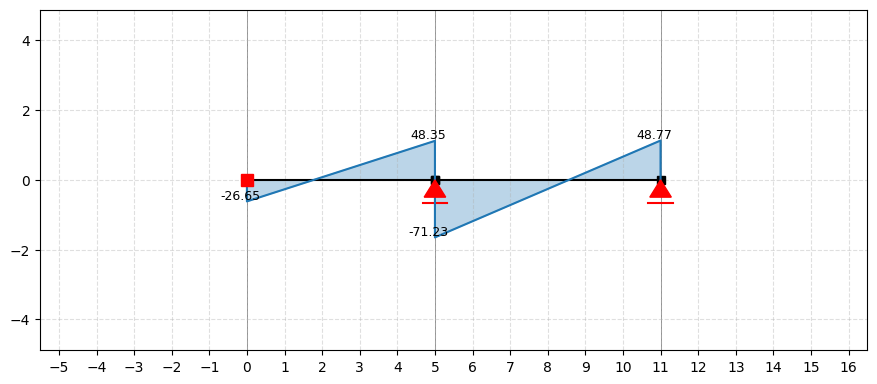

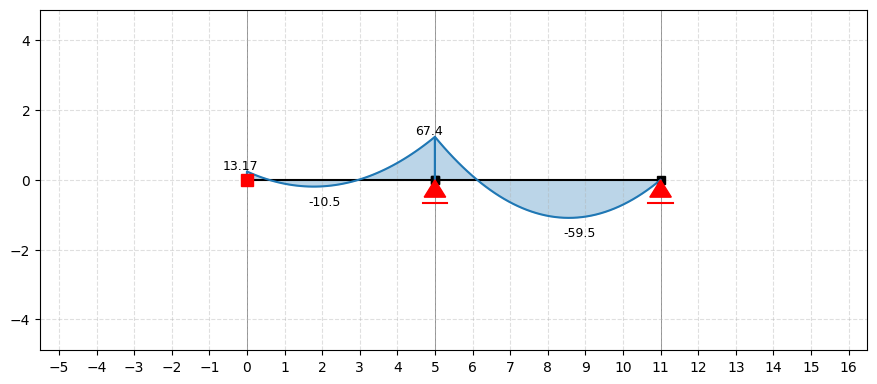

In [5]:
from anastruct import SystemElements
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

L1, L2, w1, w2 = 5.0, 6.0, 15.0, 20.0
ss = SystemElements(EA=1e8, EI=15000.0)
ss.add_element(location=[[0, 0], [L1, 0]])
ss.add_element(location=[[L1, 0], [L1 + L2, 0]])
ss.add_support_fixed(node_id=1)
ss.add_support_roll(node_id=2, direction='x')
ss.add_support_roll(node_id=3, direction='x')
ss.q_load(element_id=1, q=-w1)
ss.q_load(element_id=2, q=-w2)
ss.solve()

print("A反力:", ss.get_node_results_system(1))
print("B反力:", ss.get_node_results_system(2))
print("C反力:", ss.get_node_results_system(3))

def apply_grid(fig, supports):
    ax = fig.axes[0]
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(True, linestyle='--', alpha=0.4)
    for x in supports:
        ax.axvline(x, color='gray', lw=0.6, zorder=0)
    return fig

fig_s = ss.show_structure(show=False, figsize=(9, 3))
apply_grid(fig_s, [0, L1, L1 + L2])
plt.show()

fig_v = ss.show_shear_force(show=False, figsize=(9, 4))
apply_grid(fig_v, [0, L1, L1 + L2])
plt.show()

fig_m = ss.show_bending_moment(show=False, figsize=(9, 4))
apply_grid(fig_m, [0, L1, L1 + L2])
plt.show()

## 3. 剪力交叉檢查（AB跨、BC跨各自兩端，共4個端點）

In [6]:
m_ab, m_ba = 13.173076923076923, -67.40384615384616
m_bc, m_cb = 67.40384615384615, 0.0

V_ab0 = member_shear_curve(0.0, L1, w1, m_ab, -m_ba)
V_abL = member_shear_curve(L1, L1, w1, m_ab, -m_ba)
V_bc0 = member_shear_curve(0.0, L2, w2, m_bc, -m_cb)
V_bcL = member_shear_curve(L2, L2, w2, m_bc, -m_cb)
print(f"我們框架推算剪力: AB(0)={V_ab0:.3f} AB(L)={V_abL:.3f}  BC(0)={V_bc0:.3f} BC(L)={V_bcL:.3f}")

el1, el2 = ss.element_map[1], ss.element_map[2]
print(f"anastruct 實際剪力: AB(0)={el1.shear_force[0]:.3f} AB(L)={el1.shear_force[-1]:.3f}  "
      f"BC(0)={el2.shear_force[0]:.3f} BC(L)={el2.shear_force[-1]:.3f}")

assert abs(V_ab0 - el1.shear_force[0]) < 0.01
assert abs(V_abL - el1.shear_force[-1]) < 0.01
assert abs(V_bc0 - el2.shear_force[0]) < 0.01
assert abs(V_bcL - el2.shear_force[-1]) < 0.01
print("\n剪力交叉檢查通過 ✓ (兩跨、四個端點全部核對)")

我們框架推算剪力: AB(0)=-26.654 AB(L)=48.346  BC(0)=-71.234 BC(L)=48.766
anastruct 實際剪力: AB(0)=-26.654 AB(L)=48.346  BC(0)=-71.234 BC(L)=48.766

剪力交叉檢查通過 ✓ (兩跨、四個端點全部核對)
